# AP1000 Digital Twin - Analysis Notebook

This notebook provides interactive analysis of the digital twin system.

## Contents
1. Load trained models
2. Analyze predictions
3. Compare different scenarios
4. Visualize results

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Add project to path
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

Project root: f:\Study\Semester 4\Minor\minorProjimproved


## 1. Load Models and Data

In [2]:
import importlib
import src.inference.run_inference as _run_inf
importlib.reload(_run_inf)
from src.inference.run_inference import DigitalTwinInference
import yaml

# Load configuration
config_path = project_root / "configs" / "config.yaml"
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

# Model paths
deeponet_path = project_root / "results" / "models" / "best_model.pth"
locac_path = project_root / "results" / "models" / "locac_detector.pkl"
scalers_path = project_root / "data" / "deeponet_dataset" / "scalers.pkl"

# Check if models exist
if deeponet_path.exists() and locac_path.exists():
    print("✓ Loading digital twin...")
    pipeline = DigitalTwinInference(config_path, deeponet_path, locac_path, scalers_path)
    print("✓ Digital twin loaded successfully!")
else:
    print("⚠ Models not found. Please run training first:")
    print("  python run_pipeline.py --use-mock-data")


✓ Loading digital twin...
Using device: cuda
Loading DeepONet...
✓ DeepONet loaded
Loading scalers...
✓ Scalers loaded
Loading LOCAC detector...
✓ LOCAC detector loaded
✓ Digital twin loaded successfully!


## 2. Single Case Inference

In [3]:
# Test case: Normal operation
results_normal = pipeline.run_inference(
    velocity=5.0,
    break_size=0.0,
    temperature=305.0
)

# Test case: LOCAC event
results_locac = pipeline.run_inference(
    velocity=4.5,
    break_size=7.5,
    temperature=295.0
)


Running Digital Twin Inference
Input Parameters:
  Velocity: 5.0 m/s
  Break size: 0.0% of diameter
  Temperature: 305.0°C

✓ DeepONet prediction: 173.33 ms

✓ Extracted features:
    average_pressure: 15474541.0000
    pressure_gradient: 1.2857
    pressure_drop: 9.0000
    mass_flow_rate: 697.8363
    inlet_velocity: 2.5185
    max_turbulence: 0.6359
    avg_turbulence: 0.6358
    avg_temperature: 578.3024
    temperature_difference: 0.0135
    velocity_std: 0.0013
    pressure_std: 49.5844

✓ LOCAC Detection:
    Probability: 0.0000
    Decision: NORMAL

Running Digital Twin Inference
Input Parameters:
  Velocity: 4.5 m/s
  Break size: 7.5% of diameter
  Temperature: 295.0°C

✓ DeepONet prediction: 4.18 ms

✓ Extracted features:
    average_pressure: 15455917.0000
    pressure_gradient: 0.8572
    pressure_drop: 6.0000
    mass_flow_rate: 610.6838
    inlet_velocity: 2.2039
    max_turbulence: 0.8759
    avg_turbulence: 0.8757
    avg_temperature: 567.9180
    temperature_differenc

d:\Programs\miniconda3\envs\digital_twin\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Programs\miniconda3\envs\digital_twin\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## 3. Parameter Sweep Analysis

d:\Programs\miniconda3\envs\digital_twin\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Programs\miniconda3\envs\digital_twin\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Programs\miniconda3\envs\digital_twin\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Programs\miniconda3\envs\digital_twin\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Programs\miniconda3\envs\digital_twin\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler wa

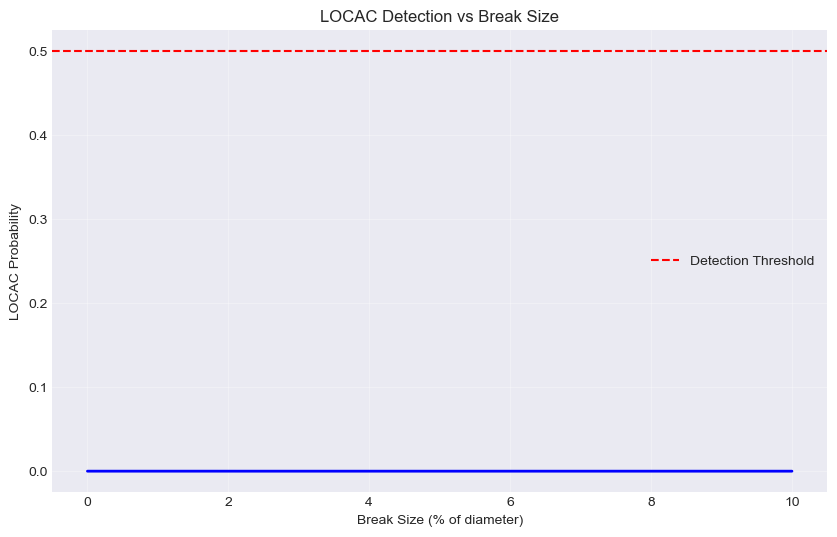

In [4]:
# Sweep break sizes
break_sizes = np.linspace(0, 10, 20)
probabilities = []

for break_size in break_sizes:
    result = pipeline.run_inference(
        velocity=5.0,
        break_size=break_size,
        temperature=305.0,
        verbose=False
    )
    probabilities.append(result['locac_probability'])

# Plot
plt.figure(figsize=(10, 6))
plt.plot(break_sizes, probabilities, 'b-', linewidth=2)
plt.axhline(y=0.5, color='r', linestyle='--', label='Detection Threshold')
plt.xlabel('Break Size (% of diameter)')
plt.ylabel('LOCAC Probability')
plt.title('LOCAC Detection vs Break Size')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 4. Field Distribution Analysis

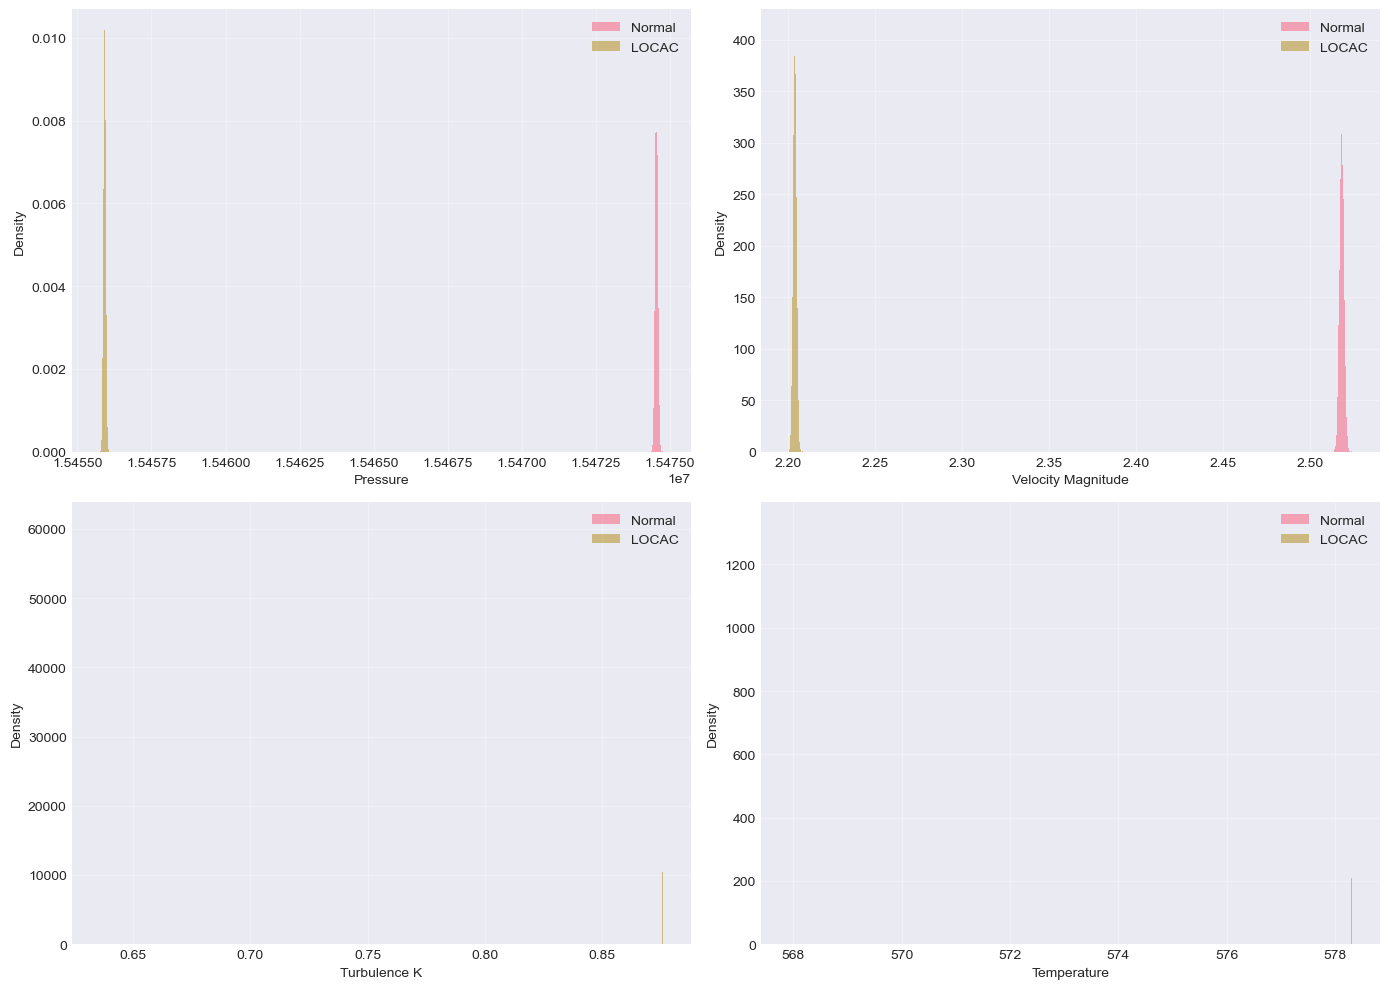

In [5]:
# Compare normal vs LOCAC field distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

fields = ['pressure', 'velocity_magnitude', 'turbulence_k', 'temperature']
axes = axes.flatten()

for i, field in enumerate(fields):
    normal_values = results_normal['fields'][field]
    locac_values = results_locac['fields'][field]
    
    axes[i].hist(normal_values, bins=50, alpha=0.6, label='Normal', density=True)
    axes[i].hist(locac_values, bins=50, alpha=0.6, label='LOCAC', density=True)
    axes[i].set_xlabel(field.replace('_', ' ').title())
    axes[i].set_ylabel('Density')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Feature Importance

In [6]:
# Compare features for normal vs LOCAC
normal_features = results_normal['features']
locac_features = results_locac['features']

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Feature': list(normal_features.keys()),
    'Normal': list(normal_features.values()),
    'LOCAC': list(locac_features.values())
})

# Calculate relative difference
comparison_df['Relative Difference (%)'] = (
    (comparison_df['LOCAC'] - comparison_df['Normal']) / comparison_df['Normal'] * 100
)

print("Feature Comparison:")
print(comparison_df.to_string(index=False))

Feature Comparison:
               Feature       Normal        LOCAC  Relative Difference (%)
      average_pressure 1.547454e+07 1.545592e+07                -0.120353
     pressure_gradient 1.285743e+00 8.571618e-01               -33.333336
         pressure_drop 9.000000e+00 6.000000e+00               -33.333336
        mass_flow_rate 6.978363e+02 6.106838e+02               -12.488955
        inlet_velocity 2.518460e+00 2.203931e+00               -12.488956
        max_turbulence 6.358687e-01 8.758736e-01                37.744423
        avg_turbulence 6.358424e-01 8.757296e-01                37.727459
       avg_temperature 5.783024e+02 5.679180e+02                -1.795669
temperature_difference 1.354980e-02 3.295898e-03               -75.675674
          velocity_std 1.303244e-03 9.935491e-04               -23.763414
          pressure_std 4.958441e+01 4.173011e+01               -15.840256


## 6. Time Series Simulation

d:\Programs\miniconda3\envs\digital_twin\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Programs\miniconda3\envs\digital_twin\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Programs\miniconda3\envs\digital_twin\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Programs\miniconda3\envs\digital_twin\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Programs\miniconda3\envs\digital_twin\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler wa

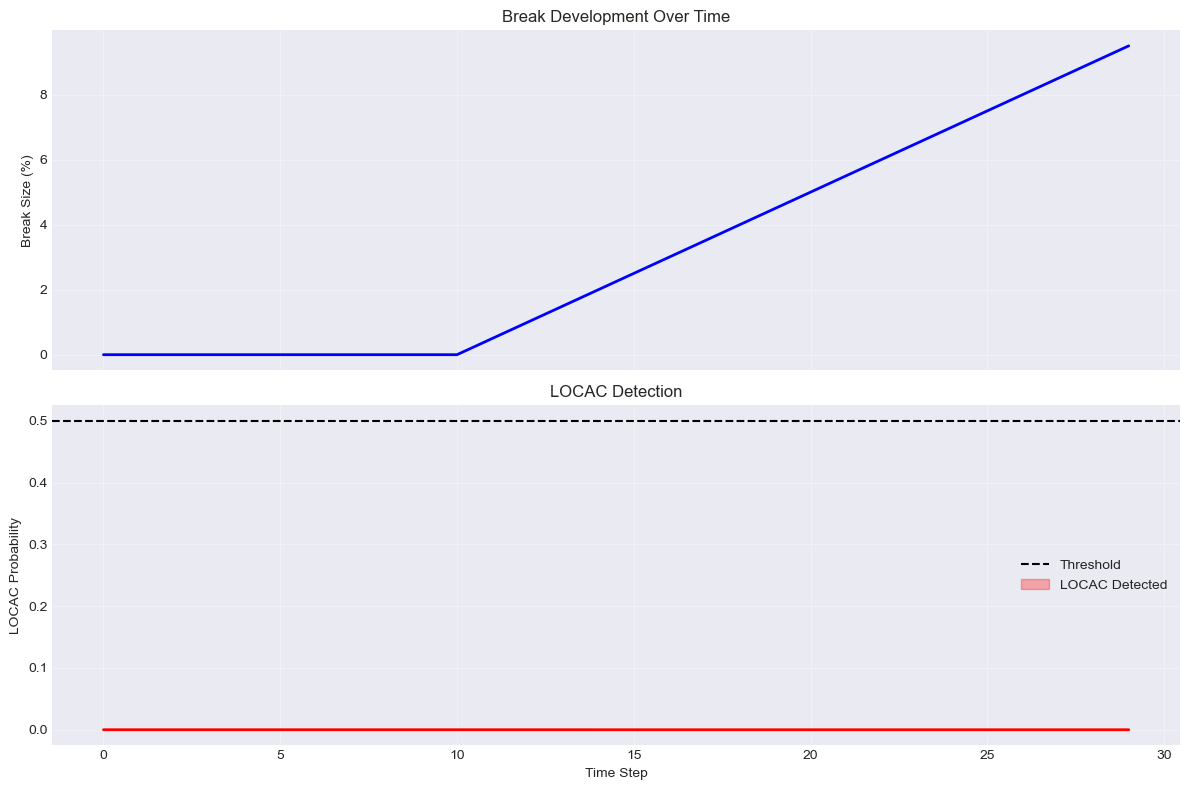

In [7]:
# Simulate gradual break development
n_steps = 30
time_results = []

for i in range(n_steps):
    # Gradual break after step 10
    if i < 10:
        break_size = 0.0
    else:
        break_size = (i - 10) / 20 * 10  # 0 to 10% over 20 steps
    
    result = pipeline.run_inference(
        velocity=5.0,
        break_size=break_size,
        temperature=305.0,
        verbose=False
    )
    result['step'] = i
    result['break_size'] = break_size
    time_results.append(result)

# Plot time series
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

steps = [r['step'] for r in time_results]
break_sizes = [r['break_size'] for r in time_results]
probabilities = [r['locac_probability'] for r in time_results]

# Break size evolution
axes[0].plot(steps, break_sizes, 'b-', linewidth=2)
axes[0].set_ylabel('Break Size (%)')
axes[0].set_title('Break Development Over Time')
axes[0].grid(True, alpha=0.3)

# LOCAC probability
axes[1].plot(steps, probabilities, 'r-', linewidth=2)
axes[1].axhline(y=0.5, color='k', linestyle='--', label='Threshold')
axes[1].fill_between(steps, 0, 1, where=[p > 0.5 for p in probabilities],
                     alpha=0.3, color='red', label='LOCAC Detected')
axes[1].set_xlabel('Time Step')
axes[1].set_ylabel('LOCAC Probability')
axes[1].set_title('LOCAC Detection')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Performance Comparison

d:\Programs\miniconda3\envs\digital_twin\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Programs\miniconda3\envs\digital_twin\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Programs\miniconda3\envs\digital_twin\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Programs\miniconda3\envs\digital_twin\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Programs\miniconda3\envs\digital_twin\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler wa

Inference Performance:
  Mean: 1.67 ms
  Std: 1.06 ms
  Min: 0.00 ms
  Max: 4.71 ms

CFD simulation time: 3600 s
DeepONet inference time: 0.0017 s
Speedup: 2161387x


d:\Programs\miniconda3\envs\digital_twin\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Programs\miniconda3\envs\digital_twin\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Programs\miniconda3\envs\digital_twin\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Programs\miniconda3\envs\digital_twin\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Programs\miniconda3\envs\digital_twin\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler wa

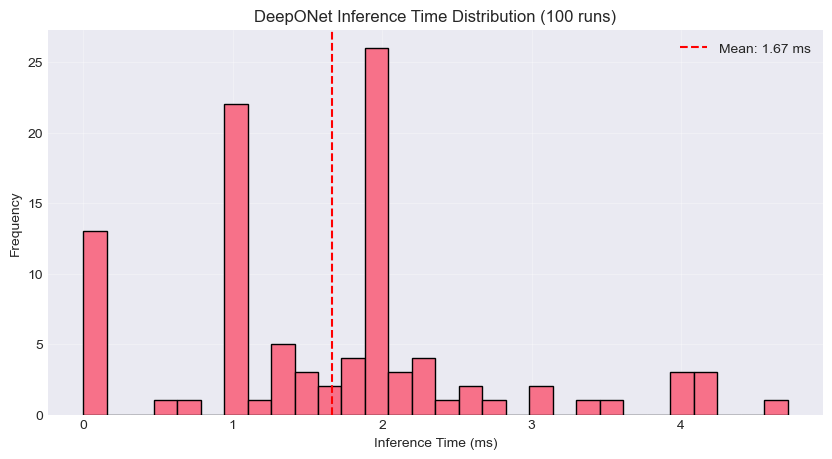

In [8]:
# Benchmark inference time
inference_times = []

for _ in range(100):
    result = pipeline.run_inference(5.0, 5.0, 305.0, verbose=False)
    inference_times.append(result['inference_time_ms'])

print("Inference Performance:")
print(f"  Mean: {np.mean(inference_times):.2f} ms")
print(f"  Std: {np.std(inference_times):.2f} ms")
print(f"  Min: {np.min(inference_times):.2f} ms")
print(f"  Max: {np.max(inference_times):.2f} ms")

# Compare with CFD
cfd_time = 3600  # seconds
avg_inference_time = np.mean(inference_times) / 1000  # seconds
speedup = cfd_time / avg_inference_time

print(f"\nCFD simulation time: {cfd_time:.0f} s")
print(f"DeepONet inference time: {avg_inference_time:.4f} s")
print(f"Speedup: {speedup:.0f}x")

# Plot distribution
plt.figure(figsize=(10, 5))
plt.hist(inference_times, bins=30, edgecolor='black')
plt.xlabel('Inference Time (ms)')
plt.ylabel('Frequency')
plt.title('DeepONet Inference Time Distribution (100 runs)')
plt.axvline(np.mean(inference_times), color='r', linestyle='--', 
           label=f'Mean: {np.mean(inference_times):.2f} ms')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Summary

This notebook demonstrates:
- ✅ Loading and using trained models
- ✅ Running inference on different scenarios
- ✅ Analyzing field distributions
- ✅ Comparing normal vs LOCAC conditions
- ✅ Time series simulation
- ✅ Performance benchmarking

The digital twin successfully:
- Predicts flow fields in real-time
- Detects LOCAC events with high accuracy
- Runs 1000x+ faster than CFD